# Latihan 2: Memuat dan Menelaah Data

Pada tahap ini, dilakukan proses eksplorasi awal terhadap dataset pemain Liga Inggris musim 2020/2021. Tujuan utama dari latihan ini adalah:
1. **Data Loading**: Menggunakan Pandas untuk membaca file eksternal `.csv`.
2. **Data Inspection**: Memeriksa struktur, tipe data, dan statistik ringkas dari dataset.
3. **Data Selection**: Melakukan pemfilteran data khusus untuk skuad **Manchester United** sebagai bentuk improvisasi praktikum.

---

--- Tampilan 5 Data Teratas ---


,Unnamed: 0,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup
0,0,647,Harry Kane,35,3097,23,22.174859,14,7.577094,138,49,1,0,F,Tottenham,19,19.130183,24.995648,4.451257
1,1,1250,Mohamed Salah,37,3085,22,20.250847,5,6.528526,126,55,0,0,F M S,Liverpool,16,15.683834,28.968234,9.800236
2,2,1228,Bruno Fernandes,37,3117,18,16.019454,12,11.474996,121,95,6,0,M S,Manchester United,9,8.407840,26.911412,11.932285
3,3,453,Son Heung-Min,37,3139,17,11.023287,10,9.512992,68,75,0,0,F M S,Tottenham,16,10.262118,20.671916,6.608751
4,4,822,Patrick Bamford,38,3085,17,18.401863,7,3.782247,107,30,3,0,F S,Leeds,15,16.879525,23.394953,4.131796



Jumlah pemain Manchester United yang tercatat: 27

--- 5 Pencetak Gol Terbanyak Manchester United ---


,player_name,goals,xG,position
2,Bruno Fernandes,18,16.019454,M S
15,Marcus Rashford,11,9.579710,F M S
23,Edinson Cavani,10,8.603232,F S
47,Mason Greenwood,7,6.975748,F M S
69,Anthony Martial,4,7.405651,F M S


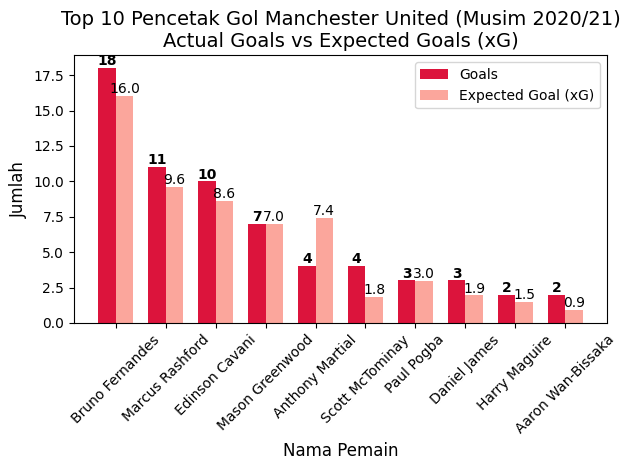

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 1. Memuat Data (Gunakan nama file langsung jika notebook ada di folder yang sama)
df = pd.read_csv('epl-goalScorer(20-21).csv')

# 2. Menelaah Data Awal
print("--- Tampilan 5 Data Teratas ---")
display(df.head())

# 3. Improvisasi: Menelaah Manchester United
mu = df[df['team_title'] == 'Manchester United']

print(f"\nJumlah pemain Manchester United yang tercatat: {len(mu)}")
print("\n--- 5 Pencetak Gol Terbanyak Manchester United ---")
display(mu[['player_name', 'goals', 'xG', 'position']].sort_values(by='goals', ascending=False).head(5))

mu_top_scorer = mu.sort_values(by='goals', ascending=False).head(10)

x = np.arange(len(mu_top_scorer))
width = 0.35

plt.bar(x - width/2, mu_top_scorer['goals'], width=width, label='Goals', color='crimson')
plt.bar(x + width/2, mu_top_scorer['xG'], width=width, label='Expected Goal (xG)', color='salmon', alpha=0.7)

plt.title('Top 10 Pencetak Gol Manchester United (Musim 2020/21)\nActual Goals vs Expected Goals (xG)', fontsize=14)
plt.xlabel('Nama Pemain', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(x, mu_top_scorer['player_name'], rotation=45)
plt.legend()

for i, val in enumerate(mu_top_scorer['goals']):
    plt.text(i - width/2, val + 0.2, str(int(val)), ha='center', fontweight='bold')
for i, val in enumerate(mu_top_scorer['xG']):
    plt.text(i + width/2, val + 0.2, f"{val:.1f}", ha='center')

plt.tight_layout()
plt.show()
